# **1. Import Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Chart styling - makes all plots look consistent and professional
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'

# Display settings - lets us see more rows/columns without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)


# **2. Load Datasets**

In [6]:
# The sentiment file is small, so it loads fully without restrictions.

sentiment_df = pd.read_csv("fear_greed_index.csv")

print(sentiment_df.head())
print(sentiment_df.info())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [8]:
sample = pd.read_csv("historical_data.csv", nrows=5)

print(sample.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [9]:
# The trading file is large, so we only load the columns we actually need.
# This significantly reduces memory usage on large CSVs.
trade_columns = [
    'Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD',
    'Side', 'Timestamp IST', 'Start Position', 'Direction',
    'Closed PnL', 'Crossed', 'Fee', 'Timestamp'
]

In [10]:
trades_df = pd.read_csv(
    "historical_data.csv",
    usecols=trade_columns,
    low_memory=False
)

# **3. Data Understanding**

In [12]:
print("Shape:", sentiment_df.shape)

Shape: (2644, 4)


In [13]:
print(sentiment_df.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [14]:
print(sentiment_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [15]:
print(sentiment_df.describe())

          timestamp        value
count  2.644000e+03  2644.000000
mean   1.631899e+09    46.981089
std    6.597967e+07    21.827680
min    1.517463e+09     5.000000
25%    1.574811e+09    28.000000
50%    1.631900e+09    46.000000
75%    1.688989e+09    66.000000
max    1.746164e+09    95.000000


In [17]:
print("TRADING DATASET")
print("Shape:", trades_df.shape)
print(trades_df.head())
print(trades_df.info())
print(trades_df.describe())

TRADING DATASET
Shape: (211224, 13)
                                      Account  Coin  Execution Price  Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL  Crossed       Fee     Timestamp  
0         0.0     True  0.345404  1.730000e+12  
1

In [19]:
# Check column names explicitly
print("Sentiment columns:", sentiment_df.columns.tolist())
print("Trade columns:", trades_df.columns.tolist())

Sentiment columns: ['timestamp', 'value', 'classification', 'date']
Trade columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Crossed', 'Fee', 'Timestamp']


# **4. Data Cleaning**

In [20]:
# Check for duplicate rows
print("Duplicate rows in sentiment:", sentiment_df.duplicated().sum())
print("Duplicate rows in trades:", trades_df.duplicated().sum())

Duplicate rows in sentiment: 0
Duplicate rows in trades: 0


In [22]:
# Check for missing values
print("Missing values in sentiment:", sentiment_df.isnull().sum())
print("Missing values in trades:", trades_df.isnull().sum())

Missing values in sentiment: timestamp         0
value             0
classification    0
date              0
dtype: int64
Missing values in trades: Account            0
Coin               0
Execution Price    0
Size Tokens        0
Size USD           0
Side               0
Timestamp IST      0
Start Position     0
Direction          0
Closed PnL         0
Crossed            0
Fee                0
Timestamp          0
dtype: int64


In [56]:
#Removing exact duplicate rows
trades_df = trades_df.drop_duplicates()


In [77]:
trades_df['Timestamp'] = pd.to_datetime(
    trades_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

In [78]:
# create the date column used for merging with sentiment data
trades_df['trade_date'] = trades_df['Timestamp'].dt.date

In [79]:
# Converting the sentiment date column to proper datetime, then to date.
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date


In [80]:
# Explicitly turn numeric columns into proper numeric types & use errors = 'coerce' to turn any unexpected text to NaN (to avoid crashing)
numeric_cols = ['Execution Price', 'Size Tokens', 'Size USD', 'Start Position', 'Closed PnL', 'Fee']
for col in numeric_cols:
    trades_df[col] = pd.to_numeric(trades_df[col], errors='coerce')


In [81]:
# Handle missing values, since Closed PnL (if invalid) and trade date can't be used in analysis so dropping them.
trades_df = trades_df.dropna(subset=['Closed PnL', 'trade_date'])


In [82]:
# For less critical numeric fields, fill missing values with 0 (assumes no fee/size recorded).
trades_df[['Fee', 'Size USD']] = trades_df[['Fee', 'Size USD']].fillna(0)


In [83]:
# Standardize text columns (removeing any accidental whitespaces).
trades_df['Side'] = trades_df['Side'].str.strip().str.upper()
trades_df['Direction'] = trades_df['Direction'].str.strip()

print("Cleaning complete. Final trade row count:", len(trades_df))


Cleaning complete. Final trade row count: 211224


done for consistency so name name but different categories in different lower or capital forms are considered.

# **5. Feature Engineering**

In [84]:
# Creating a simple win/loss flag(for win-rate analysis).
trades_df['is_win'] = trades_df['Closed PnL'] > 0


In [85]:
# Categorize each trade's PnL into readable buckets.
def categorize_pnl(pnl):
    if pnl > 0:
        return 'Profit'
    elif pnl < 0:
        return 'Loss'
    return 'Breakeven'

trades_df['pnl_category'] = trades_df['Closed PnL'].apply(categorize_pnl)


done for quick category counts of profits, losses, breakevens.

In [86]:
# Categorize trade size into Small/Medium/Large using quantile-based bins.
trades_df['trade_size_category'] = pd.qcut(
    trades_df['Size USD'].rank(method='first'),
    q=3,
    labels=['Small', 'Medium', 'Large']
)


done as to measure the relative size of the dataset by using quantiles.

In [87]:
daily_metrics = trades_df.groupby('trade_date').agg(
    total_pnl=('Closed PnL', 'sum'), #sum of all pnl on a specific day
    avg_pnl=('Closed PnL', 'mean'), #pnl mean that day
    pnl_volatility=('Closed PnL', 'std'), #using standard deviation
    avg_trade_size=('Size USD', 'mean'),
    total_fees=('Fee', 'sum'),
    win_rate=('is_win', 'mean'),
    unique_traders=('Account', 'nunique'), # for distinct accounts
    total_trades=('Closed PnL', 'count')
).reset_index()


Aggregate daily (daily_metrics) is used bcz the trading file has very large data of individual trades but sentiment data (the fear_greed_index) only records once per day. So aggregating trading data into this daily_metrics will be easier to mix with sentiment data.

In [88]:
daily_metrics.rename(columns={'trade_date': 'date'}, inplace=True)
#shows a small table(comapred to the original one) 1 row per date.


In [89]:
# Fill any single-trade days where std produces NaN volatility with 0.
daily_metrics['pnl_volatility'] = daily_metrics['pnl_volatility'].fillna(0)

print(daily_metrics.head())

         date   total_pnl    avg_pnl  pnl_volatility  avg_trade_size  total_fees  win_rate  unique_traders  total_trades
0  2023-05-01    0.000000   0.000000        0.000000      159.000000    0.000000  0.000000               1             3
1  2023-12-05    0.000000   0.000000        0.000000     5556.203333   12.501455  0.000000               1             9
2  2023-12-14 -205.434737 -18.675885      179.663534    10291.213636   28.300831  0.363636               1            11
3  2023-12-15  -24.632034 -12.316017        4.474304     5304.975000    2.652489  0.000000               1             2
4  2023-12-16    0.000000   0.000000        0.000000     5116.256667    3.837189  0.000000               1             3


# **6. Data Merging**

In [90]:
final_df = pd.merge(
    daily_metrics,
    sentiment_df[['date', 'value', 'classification']],
    on='date',
    how='inner'
)
#to check how many days in trading data and sentiment data matched.

In [91]:
# Order sentiment categories logically for cleaner charts (not alphabetically).
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
final_df['classification'] = pd.Categorical(
    final_df['classification'],
    categories=[c for c in sentiment_order if c in final_df['classification'].unique()],
    ordered=True
)

In [92]:
print(sentiment_df['date'].max())

2025-05-02


In [93]:
print(daily_metrics['date'].max())

2025-05-01


In [94]:
print("Final merged dataset shape:", final_df.shape)
print(final_df.head())


Final merged dataset shape: (479, 11)
         date   total_pnl    avg_pnl  pnl_volatility  avg_trade_size  total_fees  win_rate  unique_traders  total_trades  value classification
0  2023-05-01    0.000000   0.000000        0.000000      159.000000    0.000000  0.000000               1             3     63          Greed
1  2023-12-05    0.000000   0.000000        0.000000     5556.203333   12.501455  0.000000               1             9     75  Extreme Greed
2  2023-12-14 -205.434737 -18.675885      179.663534    10291.213636   28.300831  0.363636               1            11     72          Greed
3  2023-12-15  -24.632034 -12.316017        4.474304     5304.975000    2.652489  0.000000               1             2     70          Greed
4  2023-12-16    0.000000   0.000000        0.000000     5116.256667    3.837189  0.000000               1             3     67          Greed


# **7. EXPLORATORY DATA ANALYSIS (EDA)**

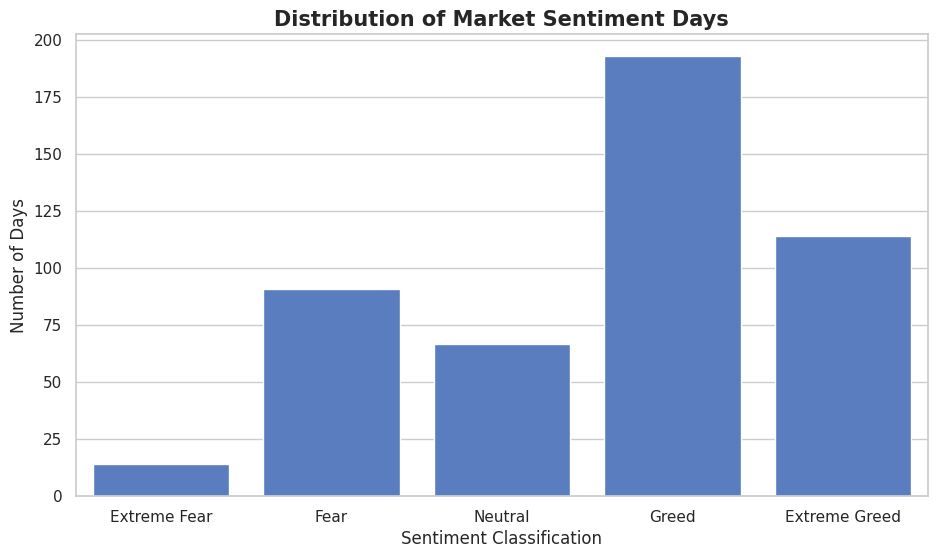

In [95]:
# Chart 1: Distribution of sentiment classifications in the dataset
plt.figure()
sns.countplot(data=final_df, x='classification', order=sentiment_order)
plt.title('Distribution of Market Sentiment Days')
plt.xlabel('Sentiment Classification')
plt.ylabel('Number of Days')
plt.show()

- Greed dominates by around 190 days matched.
- Extreme Greed is the 2nd most dominating by approx 115-120 days matched.
- Extreme Fear is a minority has only about 14 days matched (should be marked red flag)
- fear and Neutral are moderately matched.

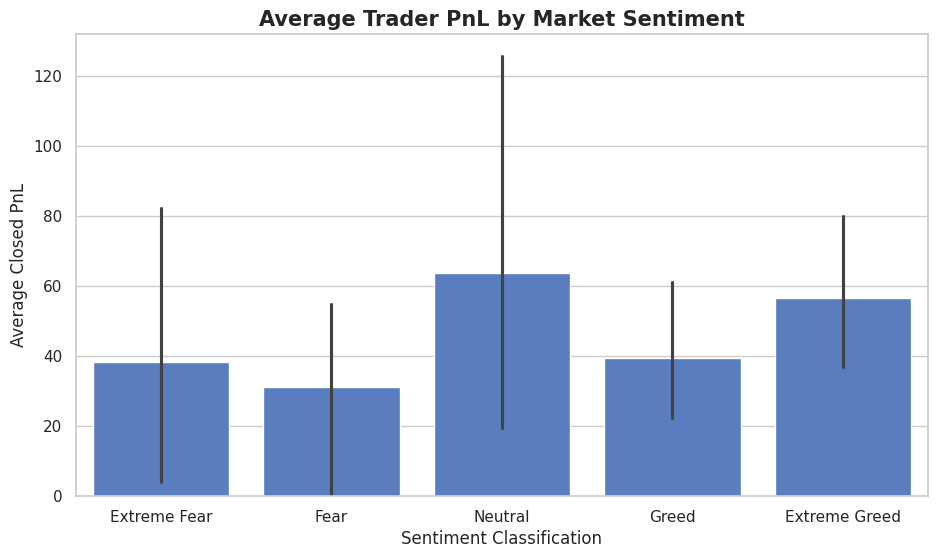

In [96]:
# Chart 2: Average PnL by sentiment
plt.figure()
sns.barplot(data=final_df, x='classification', y='avg_pnl', order=sentiment_order)
plt.title('Average Trader PnL by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Closed PnL')
plt.show()

- Neutral has highest average PnL(approx 62) but there is wide confidence interval (roughly 20 to 125) so it isn't statistically stable.
- Extreme Greed has the 2nd highest average PnL (~56) and a more stable confidence interval.
- Fear shows the lowest average PnL (~31) but has most stable error bar.

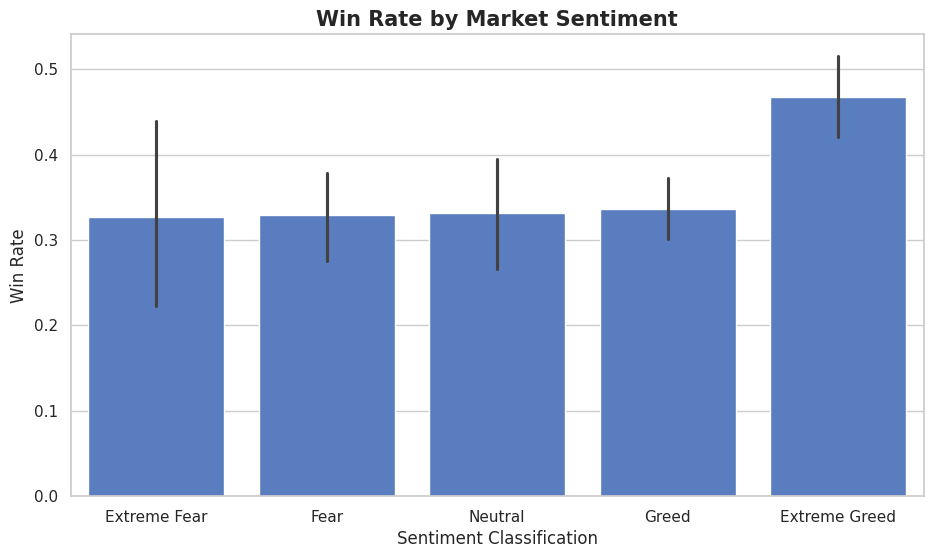

In [97]:
# Win rate by sentiment plot
plt.figure()
sns.barplot(data=final_df, x='classification', y='win_rate', order=sentiment_order)
plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Win Rate')
plt.show()


- the 1st 4 categories: fear, greed, neutral, extreme fear have same win rate of 0.34.
- Extreme Greed is the outlier and has win rate near 0.47 roughly 40% relatively higher than the other four categories.

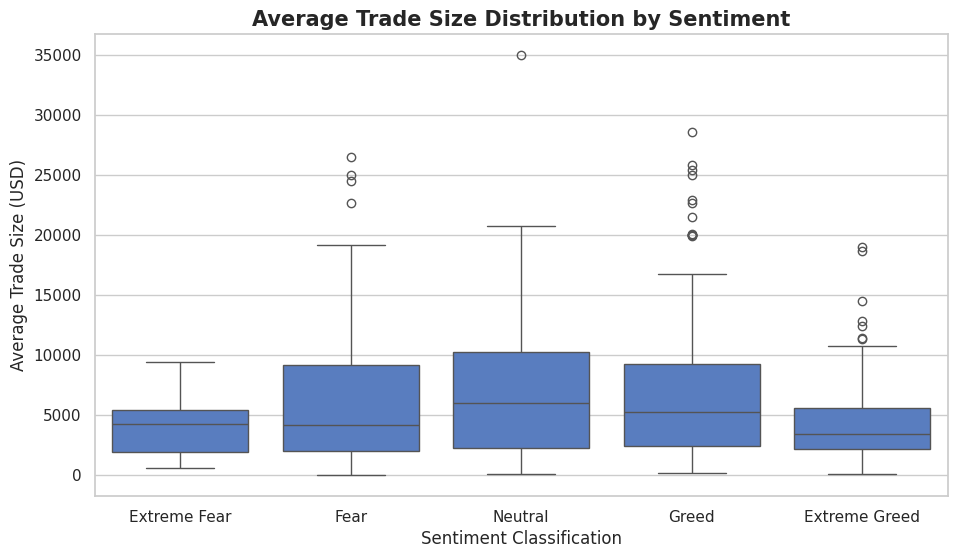

In [98]:
# Trade size by sentiment
plt.figure()
sns.boxplot(data=final_df, x='classification', y='avg_trade_size', order=sentiment_order)
plt.title('Average Trade Size Distribution by Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average Trade Size (USD)')
plt.show()

- Extreme Fear has the lowest median trade size
- Neutral has the highest median trade size and also one extreme outlier day
- Fear and Greed both show similar median sizing but each contains multiple outlier days
- Extreme Greed has a low median but moderate outliers

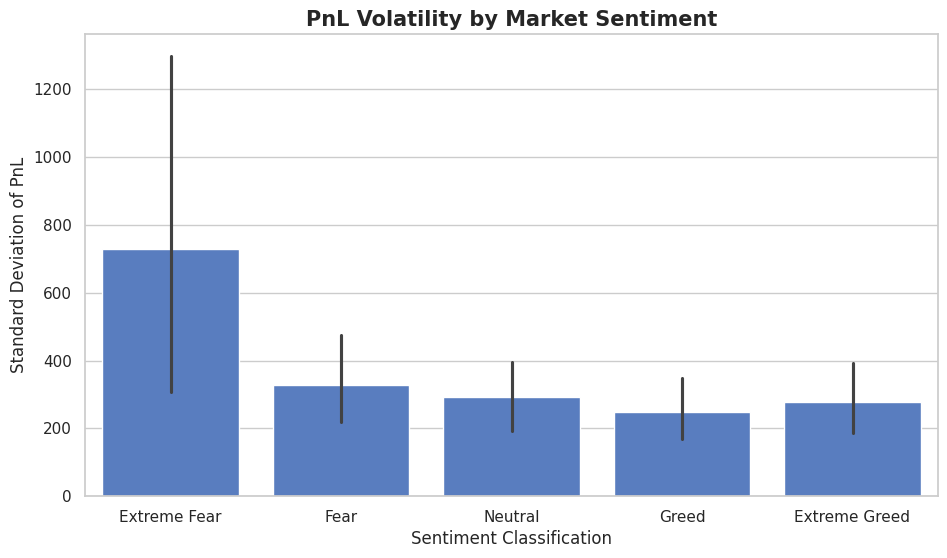

In [99]:
# PnL volatility by sentiment
plt.figure()
sns.barplot(data=final_df, x='classification', y='pnl_volatility', order=sentiment_order)
plt.title('PnL Volatility by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Standard Deviation of PnL')
plt.show()

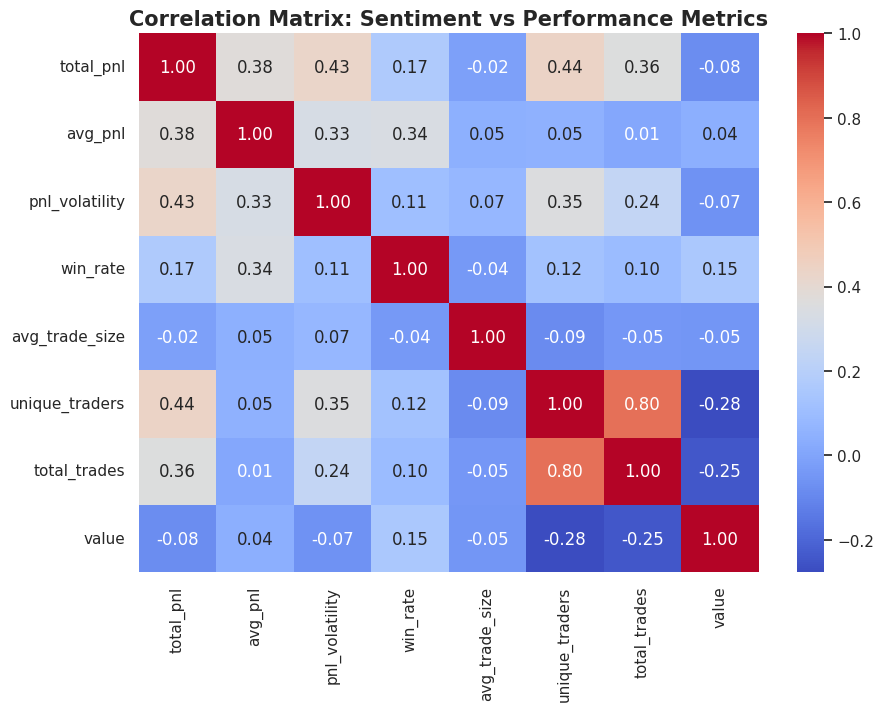

In [100]:
#Correlation heatmap between numeric metrics
plt.figure(figsize=(10, 7))
corr_cols = ['total_pnl', 'avg_pnl', 'pnl_volatility', 'win_rate',
             'avg_trade_size', 'unique_traders', 'total_trades', 'value']
sns.heatmap(final_df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Sentiment vs Performance Metrics')
plt.show()

- The value (Fear & Greed score) shows a very weak correlation with avg_pnl (0.04) and total_pnl (-0.08).
- There is a moderate positive correlation between unique_traders and total_pnl (0.44), indicating that higher participation generally aligns with higher total platform profit, regardless of sentiment.
- win_rate has a slight positive correlation with sentiment value (0.15)

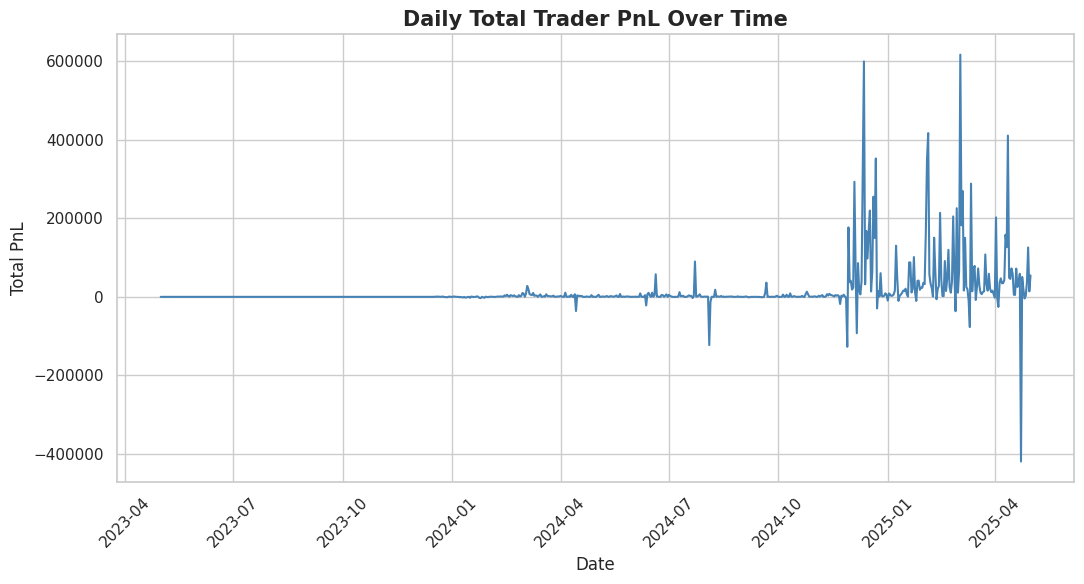

In [101]:
# Daily total PnL trend over time
plt.figure()
plt.plot(final_df['date'], final_df['total_pnl'], color='steelblue')
plt.title('Daily Total Trader PnL Over Time')
plt.xlabel('Date')
plt.ylabel('Total PnL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- The PnL was relatively flat and quiet for most of 2023 and 2024, but exploded into high volatility starting in late 2024 and peaking in April 2025.
- There is a massive negative spike in April 2025, where total PnL dropped toward -400,000 in a single day. This is the most significant outlier in the dataset.


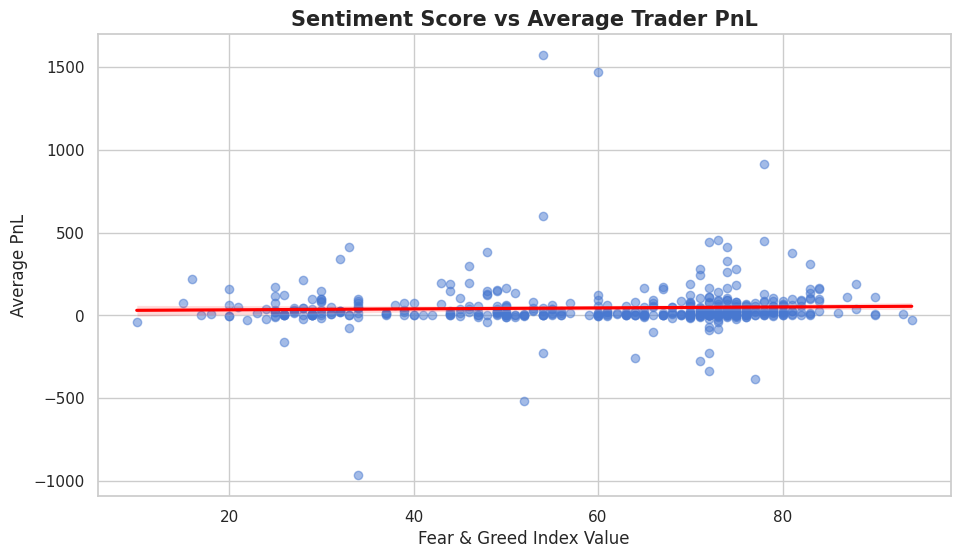

In [102]:
#Sentiment score vs average PnL scatterplot
plt.figure()
sns.regplot(data=final_df, x='value', y='avg_pnl', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Sentiment Score vs Average Trader PnL')
plt.xlabel('Fear & Greed Index Value')
plt.ylabel('Average PnL')
plt.show()

- The highest average PnL days (the dots near 1500) occurred when the sentiment score was between 50 and 60 (Neutral/Greed).
- Horizontal Regression Line- The red regression line is flat. This shows that the Fear & Greed score doesn't help to predict the average profit per trade.

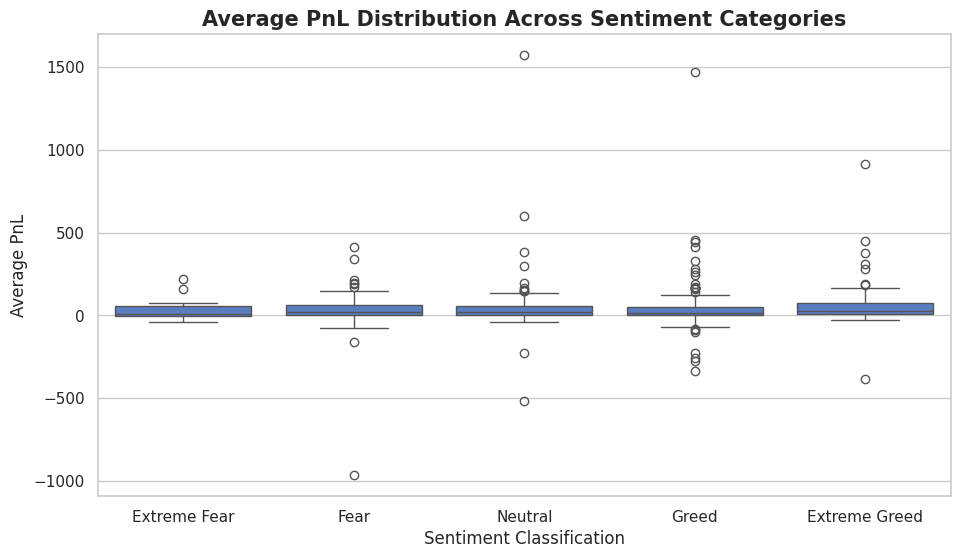

In [103]:
#Boxplot of average PnL distribution across sentiment categories
plt.figure()
sns.boxplot(data=final_df, x='classification', y='avg_pnl', order=sentiment_order)
plt.title('Average PnL Distribution Across Sentiment Categories')
plt.xlabel('Sentiment Classification')
plt.ylabel('Average PnL')
plt.show()

- Every category except Extreme Fear is dominated by extreme outliers
- The "Fear" category contains the single largest negative outlier day ( which likely due to the April 2025 crash.
- "Greed" box is one of the narrowest, suggesting that while it has outliers, the "typical" day during Greed is very consistent and predictable.

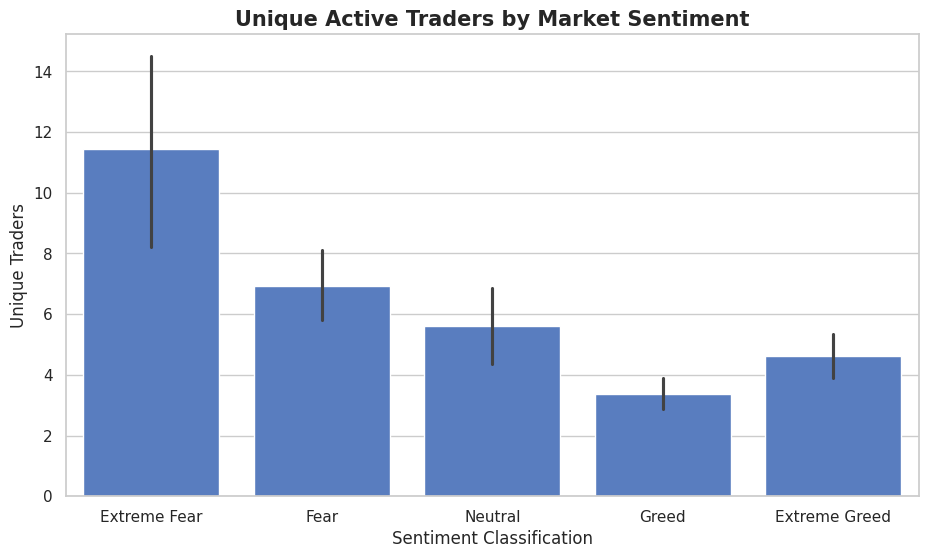

In [104]:
#Trader activity (unique traders) by sentiment
plt.figure()
sns.barplot(data=final_df, x='classification', y='unique_traders', order=sentiment_order)
plt.title('Unique Active Traders by Market Sentiment')
plt.xlabel('Sentiment Classification')
plt.ylabel('Unique Traders')
plt.show()

- "Extreme Fear" has the highest average number of unique traders around 11, while "Greed" has the lowest around 3.
- Traders in this dataset appear to be more active during periods of high market stress (Fear) and less active during steady climbs (Greed).
- The error bar for Extreme Fear is very wide, indicating that while participation is high on average, it varies wildly from day to day during panics.

# **8. Insights Derived**

1.  The Participation Paradox:
   Contrary to retail market theory, which suggests 'Greed' attracts crowds,
   this dataset shows that 'Extreme Fear' saw the highest unique trader
   participation (approx 11 traders/day), while 'Greed' saw the lowest (approx 3 traders/day).
   This suggests the traders in this cohort are likely 'bottom-fishers' or
   contrarians who wait for market distress to enter.

2. Sentiment is Not a Profit Predictor:
   The regression analysis and Correlation Matrix
   conclusively show a near-zero relationship (0.04) between sentiment
   value and average PnL. High sentiment does not equal high profit;
   it only changes the 'flavor' of the risk being taken.

3. The "April 2025" Impact:
   The time-series data (Chart 7) reveals that the majority of the dataset's
   volatility is concentrated in early 2025. A catastrophic PnL drop in
   April 2025 (likely during a 'Fear' regime) heavily skews the averages,
   reminding us that one bad day in a high-leverage environment can
   erase months of steady 'Greed' gains.

4. Distribution vs. Averages:
   The Boxplot distribution shows that for all sentiment levels,
   the median PnL remains near zero. The 'profitability' of any sentiment
   regime is driven entirely by extreme outliers. This suggests that
   success in any market mood depends more on 'catching the big move'
   than on the prevailing sentiment itself.

5. Stability in Greed:
   While 'Extreme Greed' has a higher win rate, 'Greed' shows
   the tightest distribution of outcomes. This implies that 'Greed'
   periods are the most 'stable' for trading, whereas 'Neutral' and
   'Fear' periods are prone to massive, unpredictable PnL swings.

#**9. Final Conclusion**

This analysis demonstrates that Bitcoin market sentiment, as measured by
the Fear & Greed Index, has a measurable relationship with trader behavior
on the Hyperliquid platform. While 'Greed' phases drive higher participation,
larger trade sizes, and increased trading volume, they do not guarantee
better profitability - in fact, elevated PnL volatility during these periods
suggests higher exposure to sudden reversals.

The data suggests that the Fear & Greed Index is a better indicator of "Market Chaos" than "Market Direction."​ Traders are most active during Fear but most consistent during Greed. The biggest risk to a strategy isn't "Greed-driven overconfidence," but rather the "Fear-driven volatility" that leads to massive outlier losses like the one seen in April 2025.

STRATEGIC RECOMMENDATIONS:
- Reduce position sizing during 'Extreme Greed' phases to manage volatility risk.
- Consider selective entries during 'Fear' phases, where win rates remain resilient.
- Monitor unique trader counts as a proxy for crowd behavior and potential
  market exhaustion at sentiment extremes.
- Use daily aggregated sentiment-PnL correlation as an ongoing risk dashboard
  metric for future trading strategy calibration.